# 第 6 章 OpenCV 影像數學運算

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from opencv_tools import opencv_tools # 匯入封裝的功能

### 6-1-3 本章實作共通素材準備

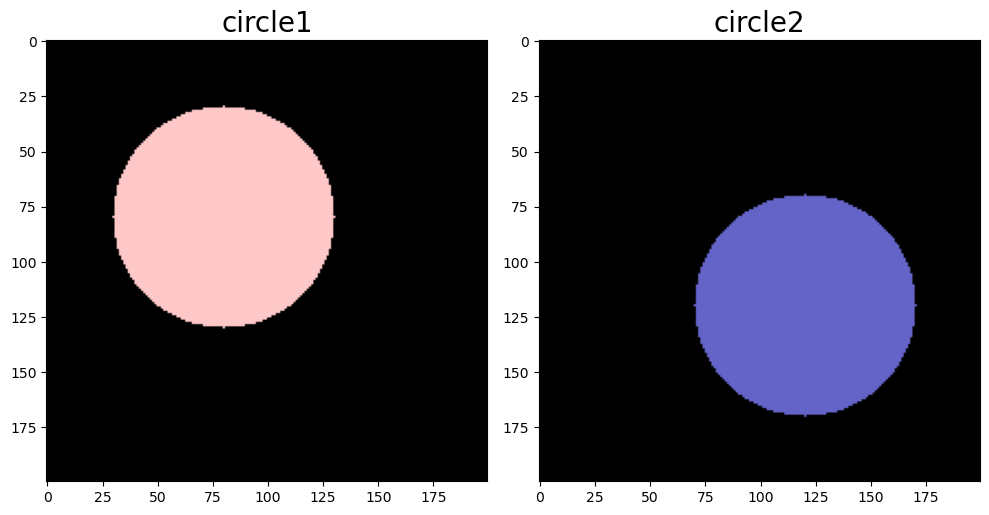

In [36]:
# 建立 200x200 的黑色背景
shape = (200, 200, 3)
circle1 = np.zeros(shape, np.uint8)
circle2 = np.zeros(shape, np.uint8)

# 畫出 circle 1
color1 = (200, 200, 255)
cv2.circle(circle1, (80, 80), 50, color1, -1)

# 畫出 circle 2
color2 = (200, 100, 100)
cv2.circle(circle2, (120, 120), 50, color2, -1)

# 1-E 封裝函式
opencv_tools.show_img_by_matplotlib_1x2(
    "circle1", circle1,
    "circle2", circle2
) 

### 6-2-3 程式範例：影像加、減法

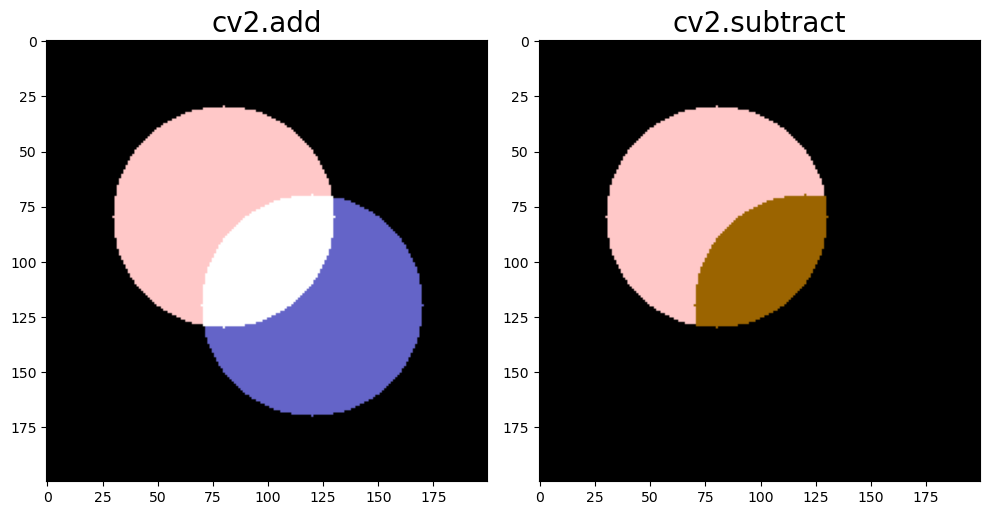

In [37]:
# 沿用 6-1-3 的 circle1. circle2
add_result = cv2.add(circle1, circle2)  # 將兩張影像做加法
subtract_result = cv2.subtract(circle1, circle2) # 將兩張影像做減法

# 1-E 封裝函式
opencv_tools.show_img_by_matplotlib_1x2(
    "cv2.add", add_result,
    "cv2.subtract", subtract_result
) 

In [38]:
# 我們可以透過取單一點的像素值，判斷結果是否正確
print(subtract_result[100, 100]) 

[  0 100 155]


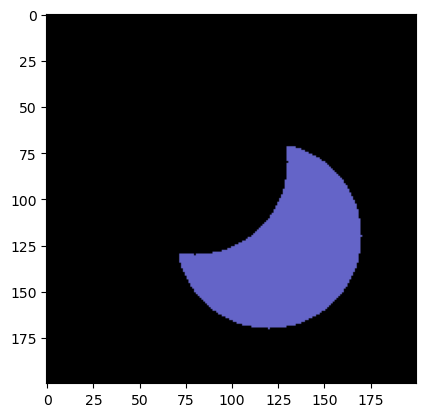

In [39]:
# 將 circle1 從 circle2 扣除，只有 circle2 有而 circle1 沒有的區域會保留
subtract_result2 = cv2.subtract(circle2, circle1)
opencv_tools.show_img_by_matplotlib(subtract_result2)

### 6-2-5 程式範例：影像絕對值差

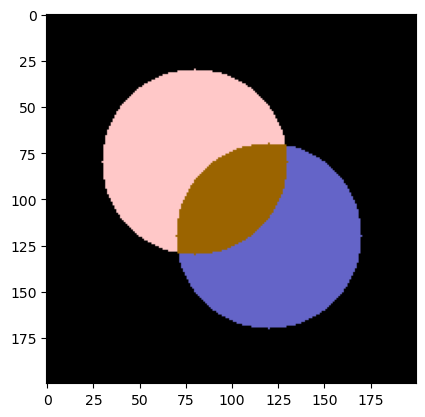

In [40]:
# 沿用 6-1-3 的 circle1, circle2
absdiff_result = cv2.absdiff(circle1, circle2)
opencv_tools.show_img_by_matplotlib(absdiff_result)

## 6-3-2 影像加權運算的範例

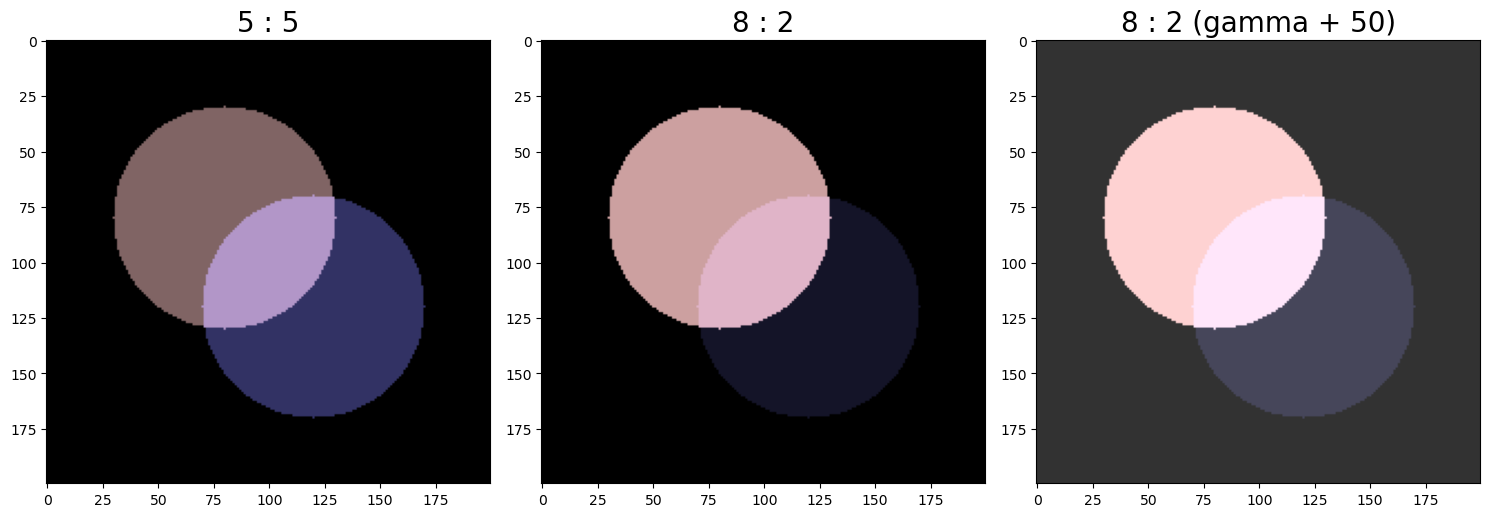

In [41]:
# 沿用 6-1 的 circle1. circle2
overlapping_5_5 = cv2.addWeighted(circle1, 0.5, circle2, 0.5, 0)
overlapping_8_2 = cv2.addWeighted(circle1, 0.8, circle2, 0.2, 0)
overlapping_8_2_50 = cv2.addWeighted(circle1, 0.8, circle2, 0.2, 50)

# 1-E 封裝函式
opencv_tools.show_img_by_matplotlib_1x3(
    "5 : 5", overlapping_5_5,
    "8 : 2", overlapping_8_2,
    "8 : 2 (gamma + 50)", overlapping_8_2_50
)

### 6-4-5 程式範例：邏輯位元的四種運算

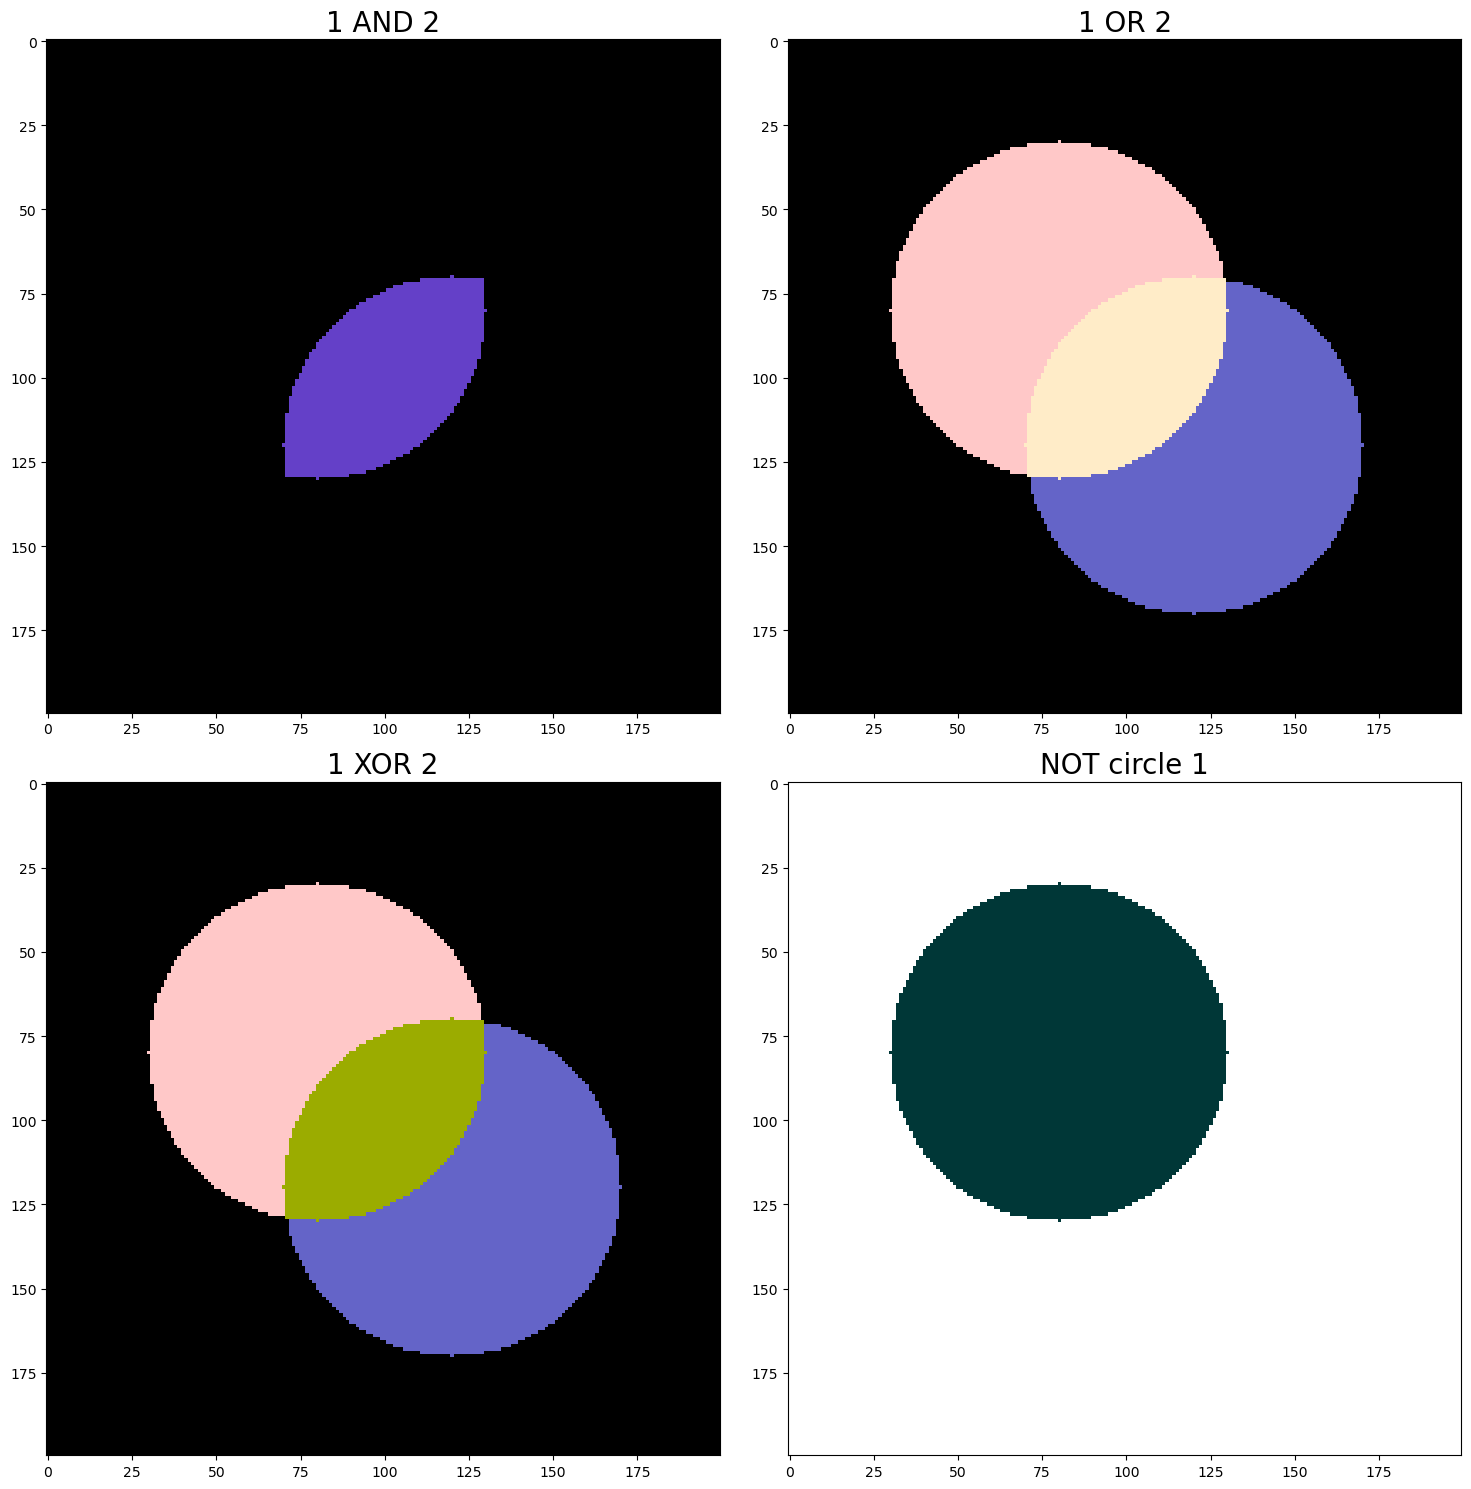

In [42]:
# 沿用 6-1 的 circle1. circle2
and_result = cv2.bitwise_and(circle1, circle2)
or_result = cv2.bitwise_or(circle1, circle2)
xor_result = cv2.bitwise_xor(circle1, circle2)
not_result1 = cv2.bitwise_not(circle1)
opencv_tools.show_img_by_matplotlib_2x2(
    "1 AND 2", and_result,
    "1 OR 2", or_result,
    "1 XOR 2", xor_result,
    "NOT circle 1", not_result1
)

In [43]:
print(and_result[100, 100])

[200  64 100]


### 6-5-1 程式範例：建立遮罩，實現區域選取

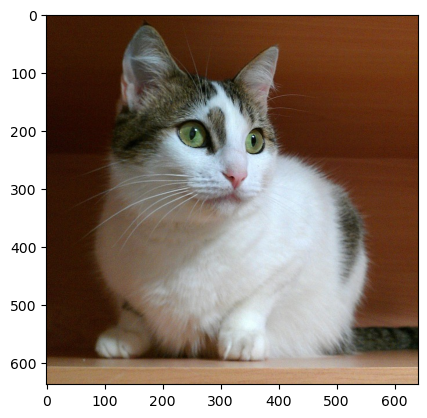

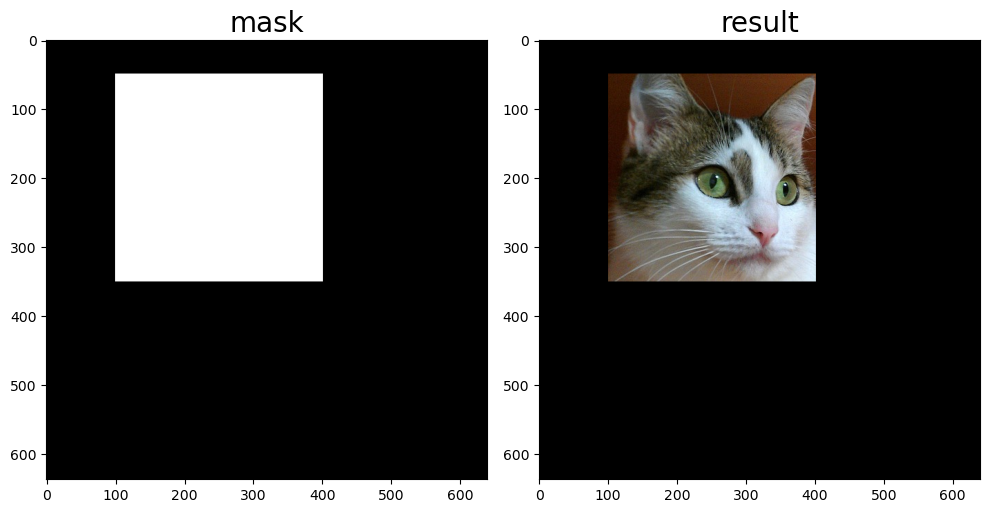

In [44]:
file_name = "sample/cat.jpg" # 請將要讀取的影像放置在與程式同一個資料夾中
img = cv2.imread(file_name) # 讀取影像
opencv_tools.show_img_by_matplotlib(img)
    
# 建立一個與影像同樣大小的黑色遮罩 (注意遮罩是單通道)
mask = np.zeros(img.shape[:2], np.uint8)

# 延續 5-E 的框選範圍
pt1 = (100, 50) # 左上角
pt2 = (400, 350) # 右下角

# 在遮罩上畫一個白色實心矩形 (白色覆蓋貓咪臉部), 一樣須注意單通道顏色只有 0~255
cv2.rectangle(mask, pt1, pt2, 255, -1) 

# 用 bitwise_and 將原圖與遮罩結合，僅顯示遮罩白色區域內的內容
result = cv2.bitwise_and(img, img, mask=mask)

opencv_tools.show_img_by_matplotlib_1x2(
    "mask", mask,
    "result", result
)

### 6-5-2 程式範例：合併多個遮罩

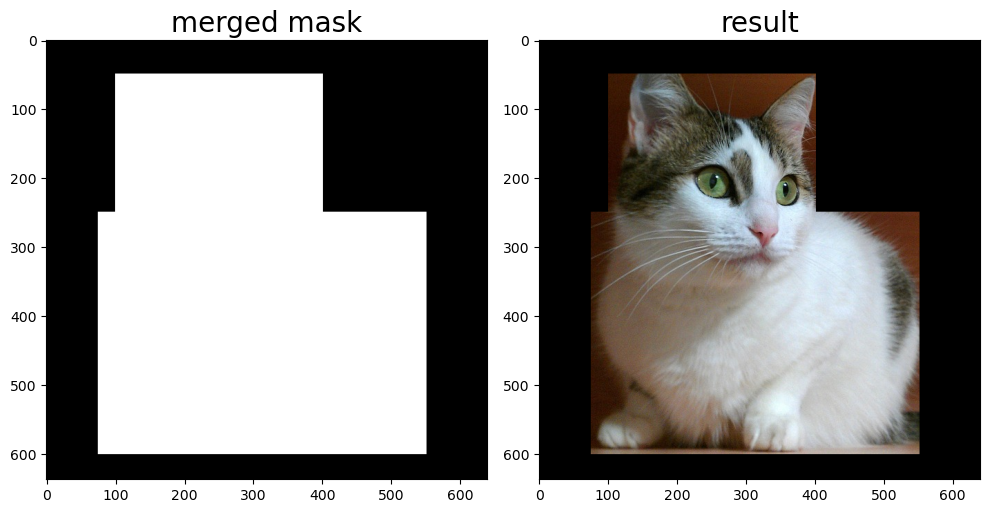

In [45]:
# 再建立一個與影像同樣大小的黑色遮罩 (注意遮罩是單通道)
mask2 = np.zeros(img.shape[:2], np.uint8)

# 遮罩上畫一個白色實心矩形 (白色覆蓋貓咪身體)
cv2.rectangle(mask2, (75, 250), (550, 600), 255, -1) 

# 合併兩個遮罩
merged_mask = cv2.bitwise_or(mask, mask2)

# 用 bitwise_and 將原圖與合併後的遮罩結合，僅顯示遮罩白色區域內的內容
cat_result = cv2.bitwise_and(img, img, mask=merged_mask)

opencv_tools.show_img_by_matplotlib_1x2(
    "merged mask", merged_mask,
    "result", cat_result
)

### 6-5-3 程式範例：比較兩張影像的差異

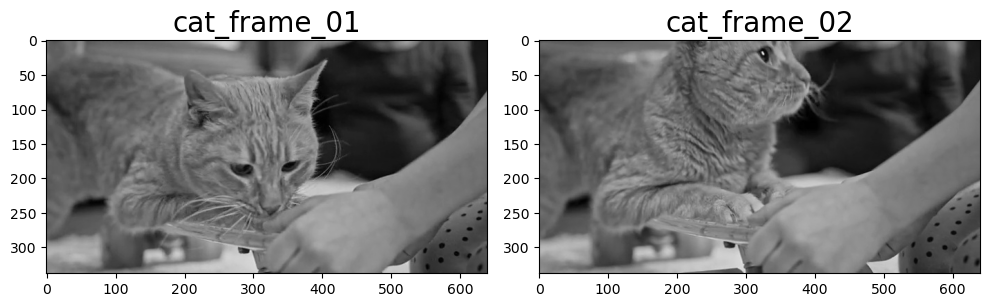

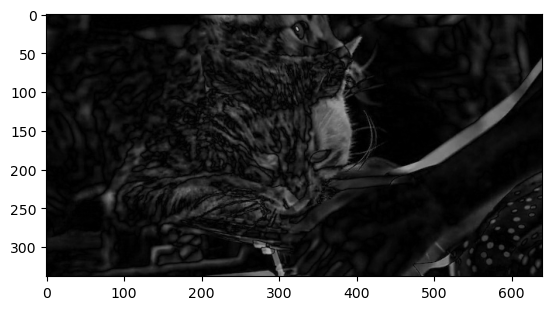

In [46]:
cat_frame_01 = cv2.imread("./sample/cat_0.jpg", cv2.IMREAD_GRAYSCALE) # 讀取第一張影像
cat_frame_02 = cv2.imread("./sample/cat_1.jpg", cv2.IMREAD_GRAYSCALE) # 讀取第二張影像


# 用 absdiff 比較前後兩張影像的差異
result = cv2.absdiff(cat_frame_01, cat_frame_02)

opencv_tools.show_img_by_matplotlib_1x2(
    "cat_frame_01", cat_frame_01,
    "cat_frame_02", cat_frame_02
)
opencv_tools.show_img_by_matplotlib(result)

* 大家來找碴的 XOR 例子

### 6-5-4 程式範例：模擬負片效果

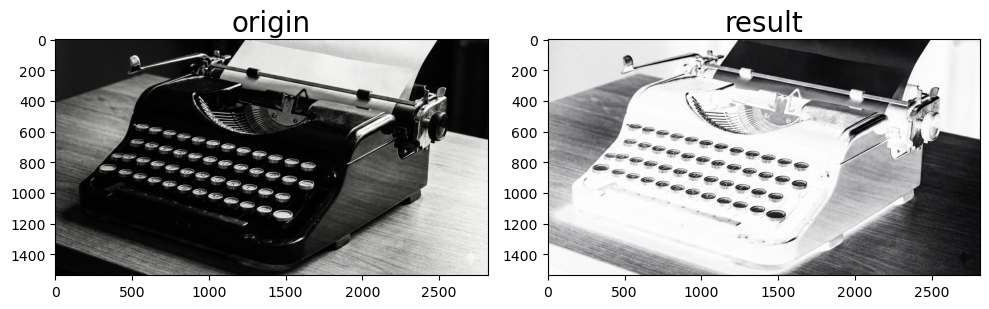

In [47]:
file_name = "sample/telephone.png"
img = cv2.imread(file_name) # 讀取影像
result = cv2.bitwise_not(img)
opencv_tools.show_img_by_matplotlib_1x2(
    "origin", img,
    "result", result
)

### 6-E-2 灰階匹配：實務上的標準做法

In [48]:
def find_diff_gray(img1, img2):
    # 轉為灰階
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # 灰階 absdiff 與 XOR
    diff_gray = cv2.absdiff(gray1, gray2)
    xor_gray = cv2.bitwise_xor(gray1, gray2)

    return diff_gray, xor_gray

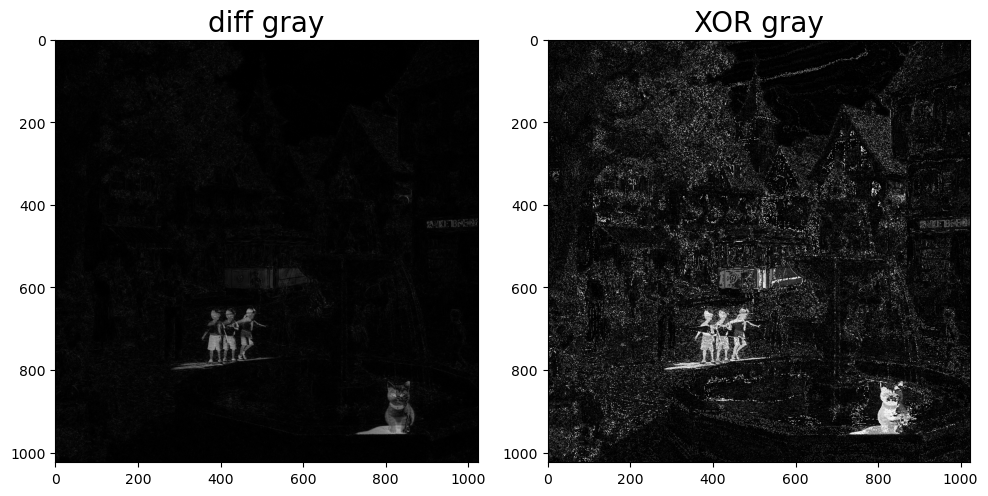

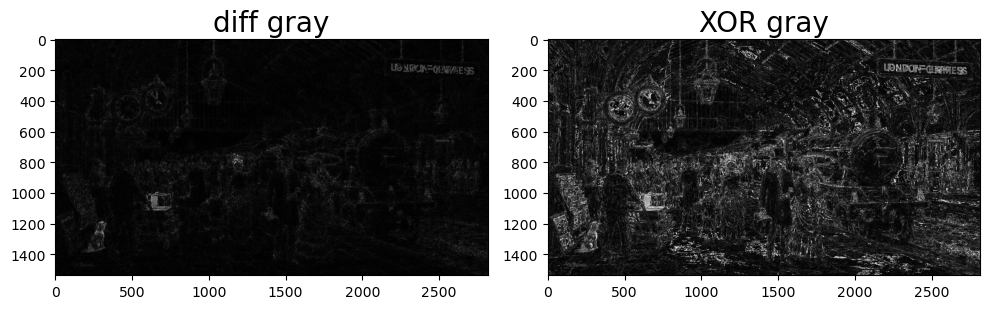

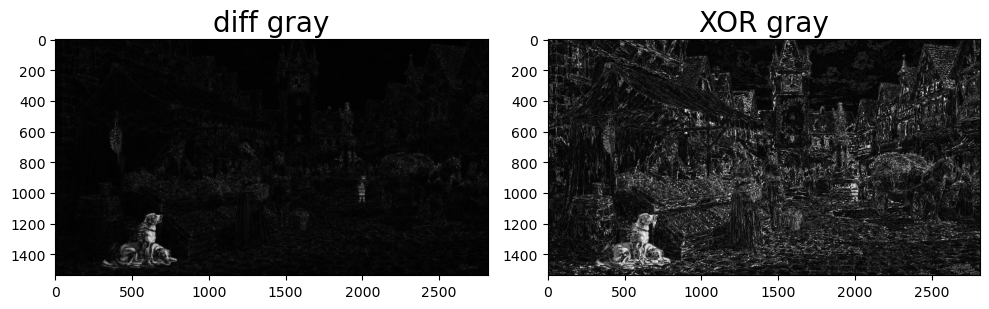

In [49]:
img1 = cv2.imread("sample/find_diff_1_1.png")
img2 = cv2.imread("sample/find_diff_1_2.png")

diff_gray, xor_gray = find_diff_gray(img1, img2)
opencv_tools.show_img_by_matplotlib_1x2(
    "diff gray", diff_gray,
    "XOR gray", xor_gray
)

img1 = cv2.imread("sample/find_diff_2_1.png")
img2 = cv2.imread("sample/find_diff_2_2.png")

diff_gray, xor_gray = find_diff_gray(img1, img2)
opencv_tools.show_img_by_matplotlib_1x2(
    "diff gray", diff_gray,
    "XOR gray", xor_gray
)

img1 = cv2.imread("sample/find_diff_3_1.png")
img2 = cv2.imread("sample/find_diff_3_2.png")

diff_gray, xor_gray = find_diff_gray(img1, img2)
opencv_tools.show_img_by_matplotlib_1x2(
    "diff gray", diff_gray,
    "XOR gray", xor_gray
)

### 6-E-3 彩色匹配：針對顏色替換的進階做法

In [50]:
def find_diff_color(img1, img2):
    # 彩色 absdiff 與 XOR
    diff_color = cv2.absdiff(img1, img2)
    xor_color = cv2.bitwise_xor(img1, img2)

    return diff_color, xor_color

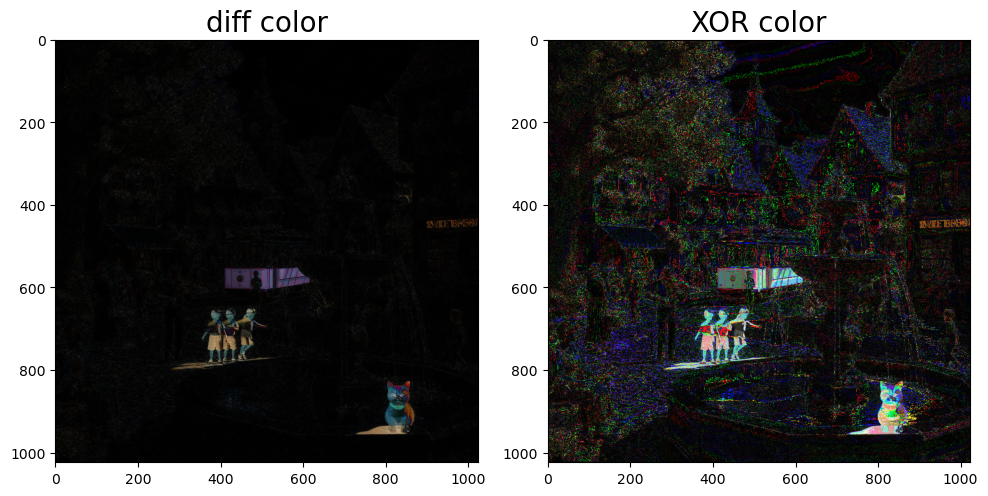

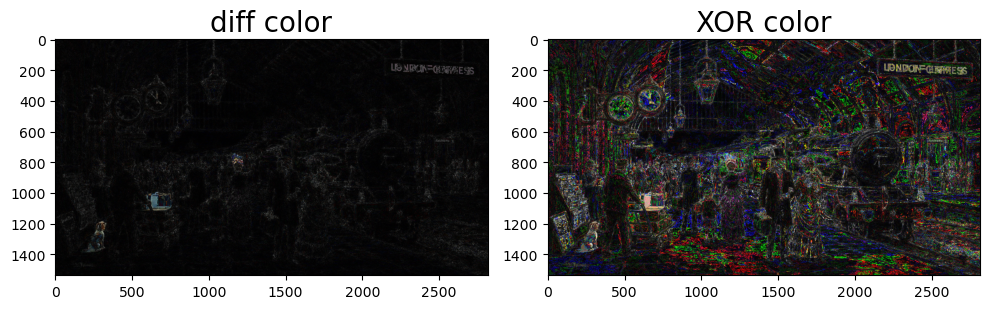

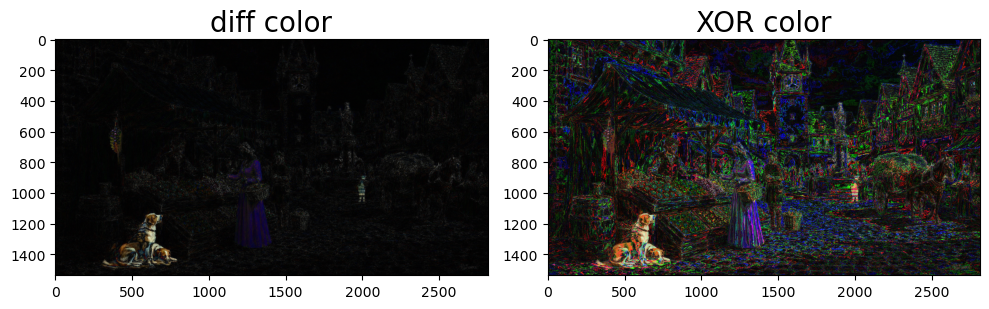

In [51]:
img1 = cv2.imread("sample/find_diff_1_1.png")
img2 = cv2.imread("sample/find_diff_1_2.png")

diff_color, xor_color = find_diff_color(img1, img2)
opencv_tools.show_img_by_matplotlib_1x2(
    "diff color", diff_color,
    "XOR color", xor_color
)

img1 = cv2.imread("sample/find_diff_2_1.png")
img2 = cv2.imread("sample/find_diff_2_2.png")

diff_color, xor_color = find_diff_color(img1, img2)
opencv_tools.show_img_by_matplotlib_1x2(
    "diff color", diff_color,
    "XOR color", xor_color
)

img1 = cv2.imread("sample/find_diff_3_1.png")
img2 = cv2.imread("sample/find_diff_3_2.png")

diff_color, xor_color = find_diff_color(img1, img2)
opencv_tools.show_img_by_matplotlib_1x2(
    "diff color", diff_color,
    "XOR color", xor_color
)